# Relatório Lab 4 — Parte A: Filtragem Espacial Passa-Baixa

**Autores:**  
Allan Hirose Pires de Souza  
Juliana dos Santos Silva  
Kaike Nascimento Souza  
**Data de realização dos experimentos:** Março de 2026  
**Data de publicação do relatório:** 10 de Março de 2026  

---

## 1. Introdução

Neste laboratório exploramos os filtros passa-baixa aplicados no processamento digital de imagens. Esses filtros atenuam as altas frequências espaciais e preservam as baixas frequências.

Filtros estudados:
- Filtro de Média
- Filtro Gaussiano
- Filtro de Mediana
- Filtro Bilateral

Cada filtro foi testado em imagens limpas e com ruído gaussiano e sal-e-pimenta, e avaliado com PSNR e SSIM.

---

## 2. Procedimentos Experimentais

- Imagens utilizadas: foto do grupo e avatar (obtidas no Lab3)
- Kernels testados: 3×3, 5×5, 11×11 e 29×29

img_grupo  shape: (470, 1538, 3)
img_avatar shape: (677, 1632, 3)


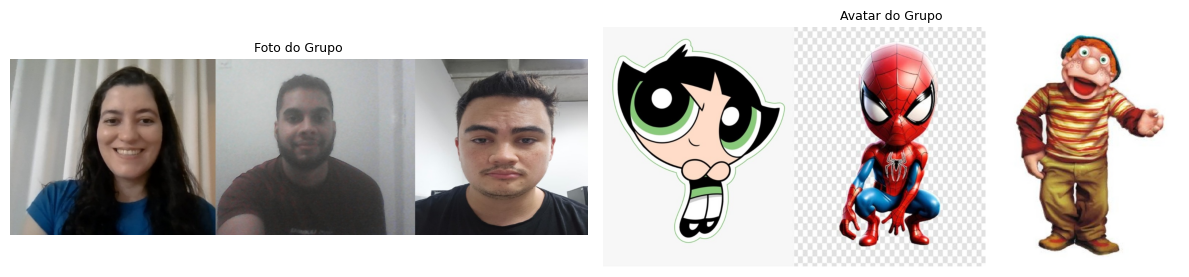

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
import warnings
warnings.filterwarnings('ignore')

def plot_images(images, titles, rows=1, cols=None, figsize=(16, 5), cmap=None):
    if cols is None:
        cols = len(images)
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    if rows * cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title, fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

img_grupo = cv2.imread('../Lab3/imagem.jpeg')
img_avatar = cv2.imread('../Lab3/avatar.jpeg')

if img_grupo is None:
    print("[AVISO] imagem.jpeg nao encontrada — usando placeholder")
    img_grupo = np.random.randint(50, 200, (400, 600, 3), dtype=np.uint8)
if img_avatar is None:
    print("[AVISO] avatar.jpeg nao encontrado — usando placeholder")
    img_avatar = np.random.randint(50, 200, (400, 400, 3), dtype=np.uint8)

img_grupo_rgb  = cv2.cvtColor(img_grupo,  cv2.COLOR_BGR2RGB)
img_avatar_rgb = cv2.cvtColor(img_avatar, cv2.COLOR_BGR2RGB)

print(f"img_grupo  shape: {img_grupo.shape}")
print(f"img_avatar shape: {img_avatar.shape}")
plot_images([img_grupo_rgb, img_avatar_rgb], ['Foto do Grupo', 'Avatar do Grupo'], figsize=(12, 5))

## 3. Item (a): Filtros em Imagens Limpas

Aplicamos os quatro filtros passa-baixa nas imagens sem ruído, variando o tamanho do kernel.

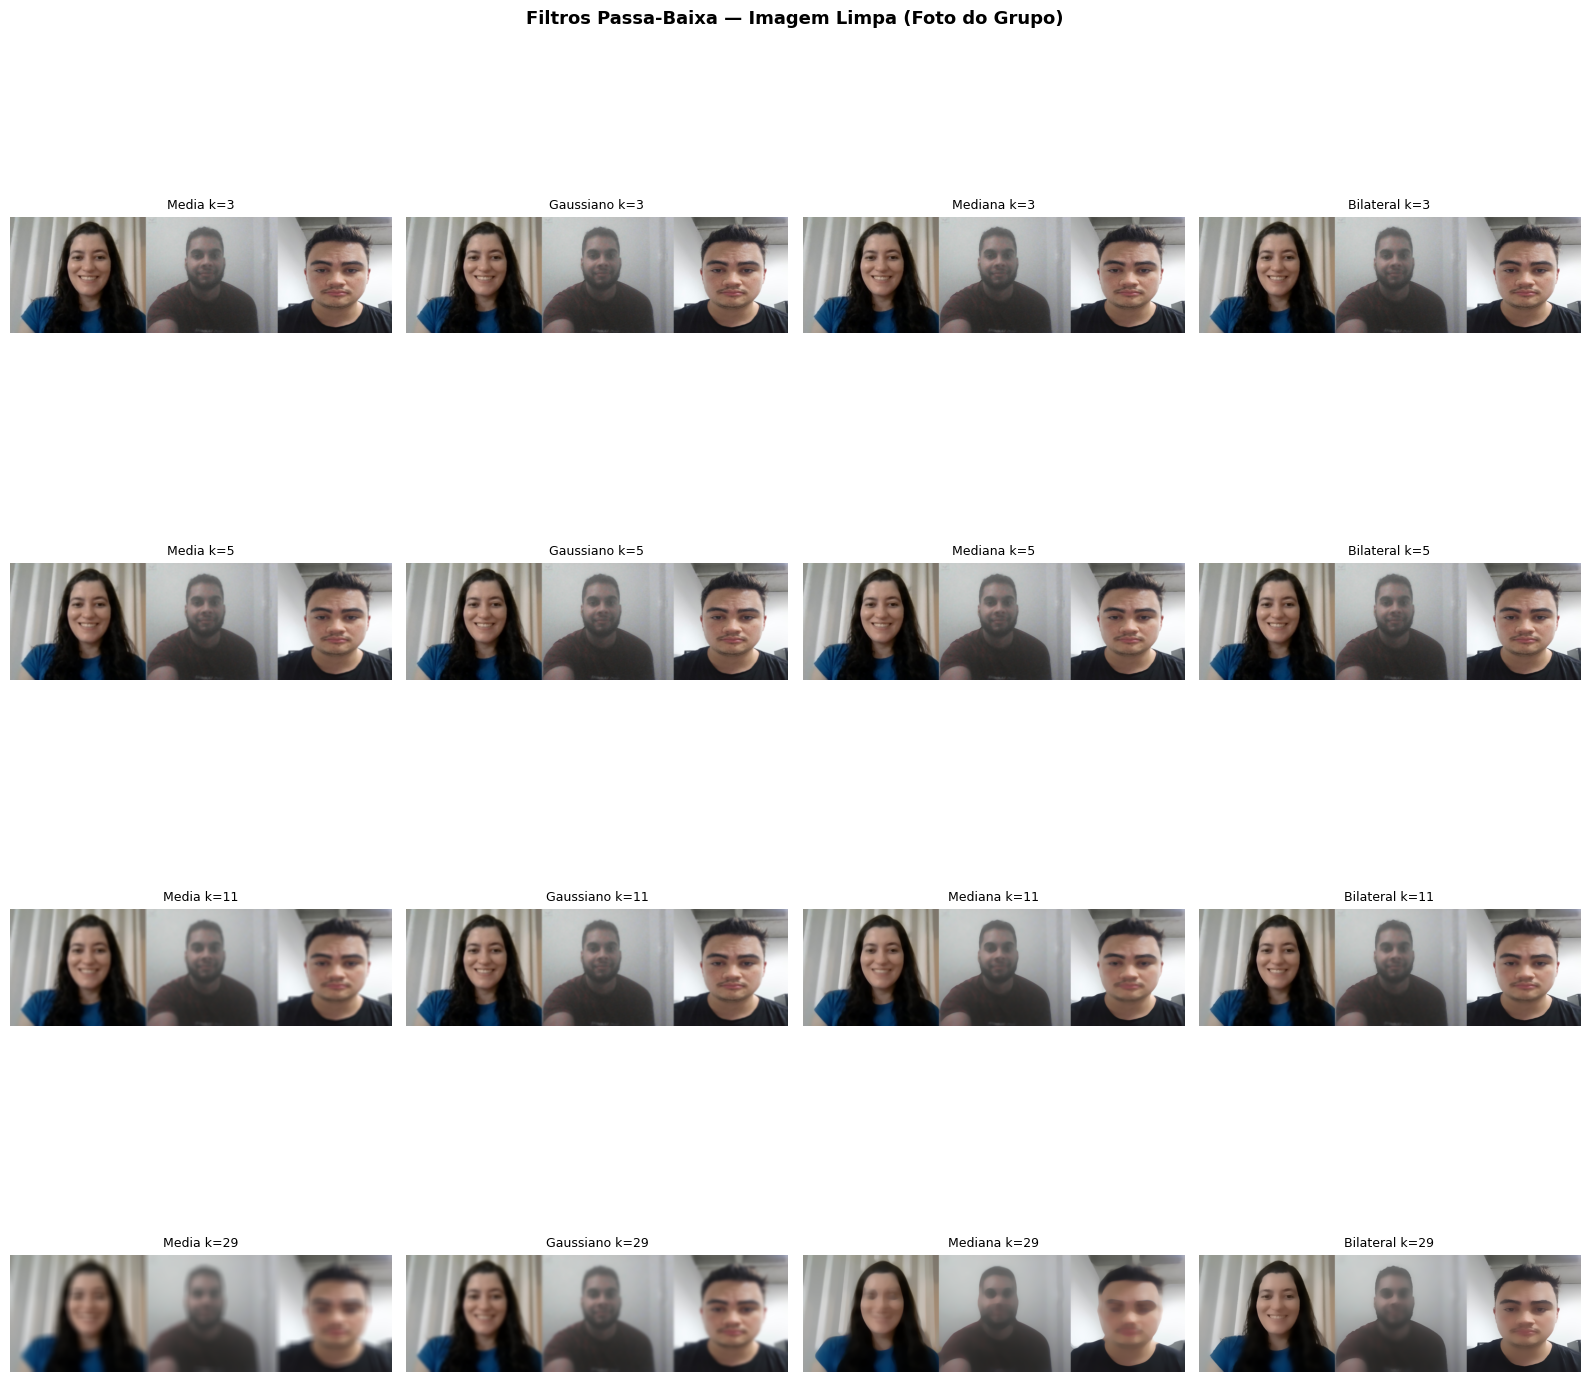

In [7]:
kernels = [3, 5, 11, 29]

fig, axes = plt.subplots(len(kernels), 4, figsize=(16, 4 * len(kernels)))
filtros_nomes = ['Media', 'Gaussiano', 'Mediana', 'Bilateral']

for row, k in enumerate(kernels):
    sigma = 0
    kp = k if k % 2 == 1 else k + 1

    blur_media     = cv2.blur(img_grupo, (k, k))
    blur_gauss     = cv2.GaussianBlur(img_grupo, (kp, kp), sigma)
    blur_mediana   = cv2.medianBlur(img_grupo, kp)
    blur_bilateral = cv2.bilateralFilter(img_grupo, k, 75, 75)

    filtrados = [blur_media, blur_gauss, blur_mediana, blur_bilateral]

    for col, (img_f, nome) in enumerate(zip(filtrados, filtros_nomes)):
        axes[row, col].imshow(cv2.cvtColor(img_f, cv2.COLOR_BGR2RGB))
        axes[row, col].set_title(f'{nome} k={k}', fontsize=9)
        axes[row, col].axis('off')

plt.suptitle('Filtros Passa-Baixa — Imagem Limpa (Foto do Grupo)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observações:**

- O filtro de média é o que mais borra, tratando todos os vizinhos com peso igual.
- O gaussiano produz borramento mais natural por conta da ponderação em sino.
- A mediana é não-linear e não cria valores novos, apenas reorganiza os existentes.
- O bilateral preserva bordas pois pondera por distância espacial e similaridade de intensidade.

## 4. Item (b): Adição de Ruído e Filtragem

Inserimos ruído gaussiano (std=50) e sal-e-pimenta (prob=5%) nas imagens e aplicamos os mesmos filtros.

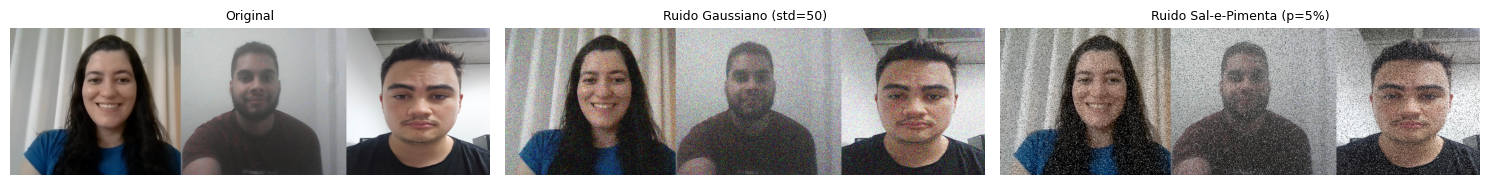

In [8]:
def adicionar_ruido_gaussiano(imagem, media=0, std=50):
    ruido = np.random.normal(media, std, imagem.shape).astype('float32')
    ruidosa = np.clip(imagem.astype('float32') + ruido, 0, 255).astype('uint8')
    return ruidosa

def adicionar_ruido_sal_pimenta(imagem, prob=0.05):
    ruidosa = np.copy(imagem)
    total_pixels = imagem.size
    n_sal = int(np.ceil(prob * total_pixels * 0.5))
    coords_sal = [np.random.randint(0, d - 1, n_sal) for d in imagem.shape[:2]]
    ruidosa[coords_sal[0], coords_sal[1]] = 255
    n_pimenta = int(np.ceil(prob * total_pixels * 0.5))
    coords_pim = [np.random.randint(0, d - 1, n_pimenta) for d in imagem.shape[:2]]
    ruidosa[coords_pim[0], coords_pim[1]] = 0
    return ruidosa

img_gauss_noise = adicionar_ruido_gaussiano(img_grupo)
img_sp_noise    = adicionar_ruido_sal_pimenta(img_grupo)

plot_images(
    [img_grupo_rgb,
     cv2.cvtColor(img_gauss_noise, cv2.COLOR_BGR2RGB),
     cv2.cvtColor(img_sp_noise,    cv2.COLOR_BGR2RGB)],
    ['Original', 'Ruido Gaussiano (std=50)', 'Ruido Sal-e-Pimenta (p=5%)'],
    figsize=(15, 5)
)

## 5. Item (c): Análise Quantitativa com PSNR e SSIM

In [9]:
def calcular_metricas(original, filtrada):
    psnr_val = cv2.PSNR(original, filtrada)
    cinza_orig = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
    cinza_filt = cv2.cvtColor(filtrada, cv2.COLOR_BGR2GRAY)
    ssim_val, _ = ssim(cinza_orig, cinza_filt, full=True)
    return psnr_val, ssim_val

k = 5
kp = k if k % 2 == 1 else k + 1

resultados = {}

for nome_ruido, img_ruidosa in [('Gaussiano', img_gauss_noise), ('Sal-e-Pimenta', img_sp_noise)]:
    resultados[nome_ruido] = {}
    for nome_filtro, img_filtrada in [
        ('Media',     cv2.blur(img_ruidosa, (k, k))),
        ('Gaussiano', cv2.GaussianBlur(img_ruidosa, (kp, kp), 0)),
        ('Mediana',   cv2.medianBlur(img_ruidosa, kp)),
        ('Bilateral', cv2.bilateralFilter(img_ruidosa, k, 75, 75)),
    ]:
        psnr_v, ssim_v = calcular_metricas(img_grupo, img_filtrada)
        resultados[nome_ruido][nome_filtro] = {'PSNR': psnr_v, 'SSIM': ssim_v}

print(f"{'Ruido':<15} {'Filtro':<12} {'PSNR (dB)':<12} {'SSIM':<8}")
print("-" * 50)
for nome_ruido, filtros in resultados.items():
    for nome_filtro, metricas in filtros.items():
        print(f"{nome_ruido:<15} {nome_filtro:<12} {metricas['PSNR']:<12.2f} {metricas['SSIM']:<8.4f}")
    print()

Ruido           Filtro       PSNR (dB)    SSIM    
--------------------------------------------------
Gaussiano       Media        26.52        0.7062  
Gaussiano       Gaussiano    25.03        0.5881  
Gaussiano       Mediana      25.93        0.6181  
Gaussiano       Bilateral    18.14        0.2254  

Sal-e-Pimenta   Media        24.59        0.5020  
Sal-e-Pimenta   Gaussiano    23.17        0.3696  
Sal-e-Pimenta   Mediana      37.32        0.9659  
Sal-e-Pimenta   Bilateral    13.56        0.0699  



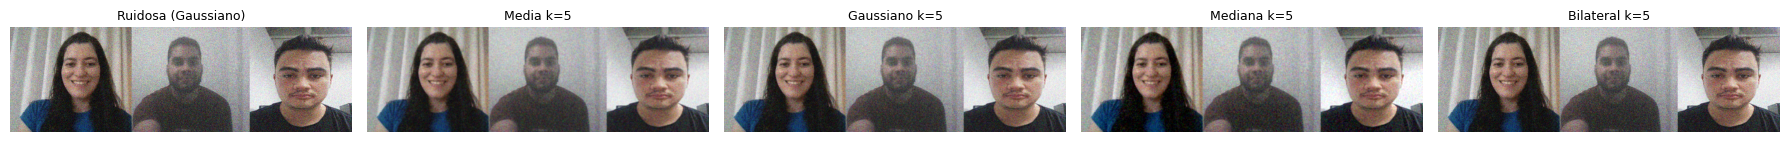

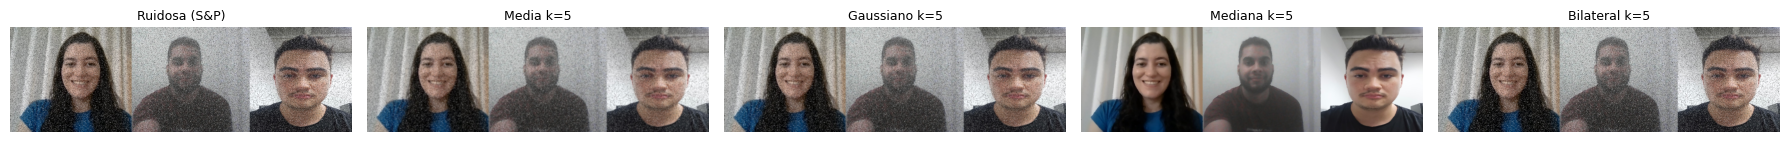

In [10]:
k, kp = 5, 5
imgs_gauss = [
    cv2.cvtColor(img_gauss_noise, cv2.COLOR_BGR2RGB),
    cv2.cvtColor(cv2.blur(img_gauss_noise, (k, k)), cv2.COLOR_BGR2RGB),
    cv2.cvtColor(cv2.GaussianBlur(img_gauss_noise, (kp, kp), 0), cv2.COLOR_BGR2RGB),
    cv2.cvtColor(cv2.medianBlur(img_gauss_noise, kp), cv2.COLOR_BGR2RGB),
    cv2.cvtColor(cv2.bilateralFilter(img_gauss_noise, k, 75, 75), cv2.COLOR_BGR2RGB),
]
titles_g = ['Ruidosa (Gaussiano)', 'Media k=5', 'Gaussiano k=5', 'Mediana k=5', 'Bilateral k=5']
plot_images(imgs_gauss, titles_g, figsize=(18, 4))

imgs_sp = [
    cv2.cvtColor(img_sp_noise, cv2.COLOR_BGR2RGB),
    cv2.cvtColor(cv2.blur(img_sp_noise, (k, k)), cv2.COLOR_BGR2RGB),
    cv2.cvtColor(cv2.GaussianBlur(img_sp_noise, (kp, kp), 0), cv2.COLOR_BGR2RGB),
    cv2.cvtColor(cv2.medianBlur(img_sp_noise, kp), cv2.COLOR_BGR2RGB),
    cv2.cvtColor(cv2.bilateralFilter(img_sp_noise, k, 75, 75), cv2.COLOR_BGR2RGB),
]
titles_sp = ['Ruidosa (S&P)', 'Media k=5', 'Gaussiano k=5', 'Mediana k=5', 'Bilateral k=5']
plot_images(imgs_sp, titles_sp, figsize=(18, 4))

## 6. Análise e Discussão

Para ruído gaussiano, os filtros de média e gaussiano tiveram PSNR parecidos. O bilateral se destacou no SSIM por preservar bordas.

Para ruído sal-e-pimenta, a mediana foi muito superior. Como é um filtro de ordem, ela descarta os valores extremos (0 e 255) sem borrar a imagem. Já os filtros lineares espalharam o ruído.

De modo geral, kernels maiores borram mais — existe um trade-off entre redução de ruído e perda de detalhes.

---

## 7. Conclusões

- Para ruído gaussiano, filtros lineares são adequados; o bilateral é bom quando queremos manter bordas.
- Para ruído sal-e-pimenta, a mediana é a melhor escolha.
- Kernels maiores sempre aumentam o borramento.

---

## Referências

- Gonzalez, R. C.; Woods, R. E. *Digital Image Processing*, 4th ed.
- OpenCV Tutorials: [Smoothing Images](https://docs.opencv.org/4.x/dc/dd3/tutorial_gausian_median_blur_bilateral_filter.html)
- OpenCV PSNR/SSIM: [Video Input PSNR SSIM](https://docs.opencv.org/4.x/d5/dc4/tutorial_video_input_psnr_ssim.html)